In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


path = r"Final_Data.csv"
df = pd.read_csv(path)
df = df[::50]  

In [ ]:

#Polynomial Regression Pipeline
Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=3)),
    ('model', LinearRegression())
]

X = df[[
 'TGS2602-1',
 'TGS2602-2',
 'TGS2600-1',
 'TGS2600-2',
 'TGS2610-1',
 'TGS2610-2',
 'TGS2620-1',
 'TGS2620-2',
 'TGS2602-3',
 'TGS2602-4',
 'TGS2600-3',
 'TGS2600-4',
 'TGS2610-3',
 'TGS2610-4',
 'TGS2620-3',
 'TGS2620-4']]

Y = df[['Ethylene con: (ppm)']]

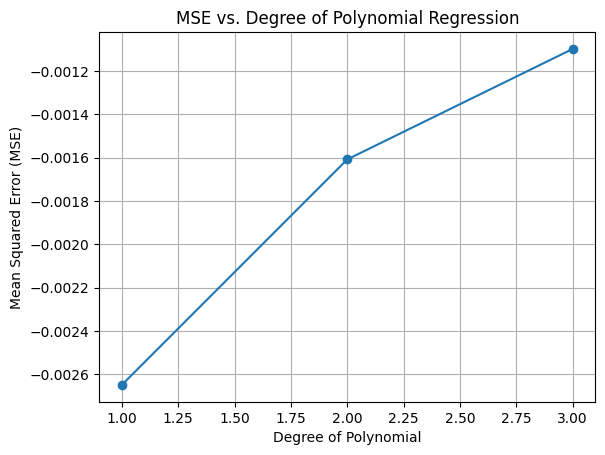

In [3]:
#Choosing Degree for Polynomial Regression

def calculate_mse(X, y, degree, cv=10):

  kfold = KFold(n_splits=cv, shuffle=True, random_state=35)
  mse_scores = []

  # Create the pipeline for each degree
  for d in range(1, degree + 1):
    pipe = Pipeline([
      ('scale', StandardScaler()),
      ('polynomial', PolynomialFeatures(degree=d)),
      ('model', LinearRegression())
    ])

    # Performing KFold cross-validation and calculate MSE
    mse_scores.append(cross_val_score(pipe, X, y, cv=kfold, scoring='neg_mean_squared_error').mean())  

  return mse_scores


max_degree = 3 

# Calculate MSE for different degrees
degrees = range(1, max_degree + 1)
mse_scores = calculate_mse(X, Y, max_degree)

# Plotting the results
import matplotlib.pyplot as plt

plt.plot(degrees, mse_scores, marker='o', linestyle='-')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Degree of Polynomial Regression')
plt.grid(True)
plt.show()


In [4]:
# Evaluation Using KFold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)  #10 Splits

#pipeline
pipe = Pipeline(Input)

# Performing KFold cross-validation and calculating mean squared error (MSE)
mse_scores = cross_val_score(pipe, X, Y, cv=kfold, scoring='neg_mean_squared_error') 
r2_scores = cross_val_score(pipe, X, Y, cv=kfold, scoring='r2')


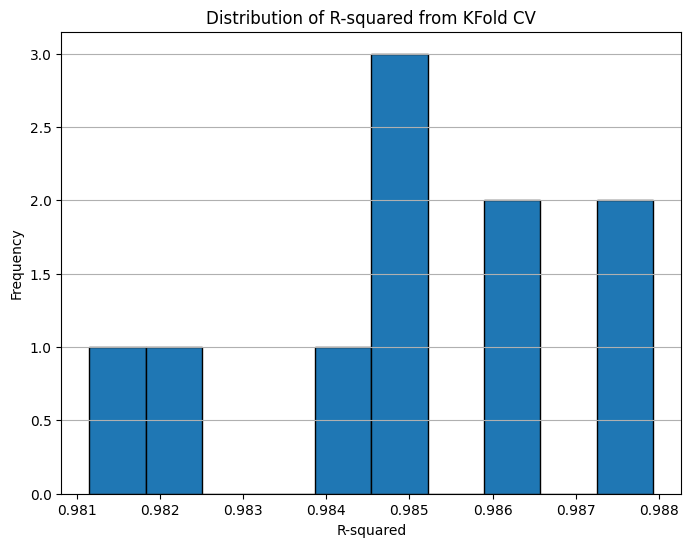

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) 
plt.hist(r2_scores, bins=10, edgecolor='black')  
plt.xlabel('R-squared')
plt.ylabel('Frequency')
plt.title('Distribution of R-squared from KFold CV')
plt.grid(axis='y')
plt.show()


In [6]:
# Printing the mean and standard deviation of MSE scores
print("Results : \n")
print(f"Average Mean Square Error / Validation Loss : {mse_scores.mean()}")
print(f"Std. Dev. of MSE : {mse_scores.std()}")
print(f"Average R-Squared : {r2_scores.mean()}")
print(f"Average R-Squared Error : {1 - r2_scores.mean()}")

Results : 

Average Mean Square Error / Validation Loss : -0.0010990435800110224
Std. Dev. of MSE : 0.0001229416983753084
Average R-Squared : 0.9849999211915513
Average R-Squared Error : 0.01500007880844867
